# Pattern Recognition 3 - Points and Neighbourhoods

**Objectives**:

* Detect points of interest in an image
* Extract neighbourhood descriptors
* Use descriptors for clustering and matching

## Points of interest

In the previous labs, we have analyzed the images either using "object descriptors" (area, eccentricity, moments of segmented object) or "image descriptors" (based on all the pixels of the image). Another way of approaching an image analysis problem is to first look for "interesting points".

What makes a point *interesting* will highly depend on the application. Common examples are **corners**, or **local extrema**.

Starting from the `mitosis.bmp` image, find or create a **point detector** that will detect the nuclei of the cells.

> *Hint: it may be easier to do so in a different color space...*

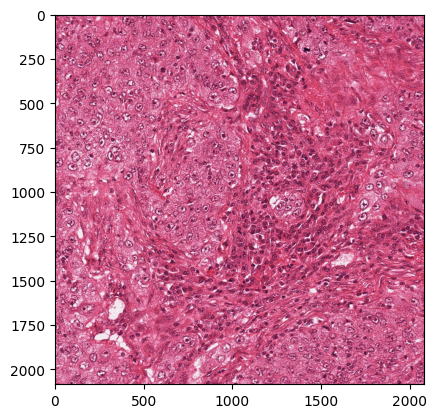

In [5]:
import numpy as np
from matplotlib import pyplot as plt
from skimage.io import imread
%matplotlib inline

im = imread('mitosis.bmp')
plt.figure()
plt.imshow(im)
plt.show()

6951 nuclei detected


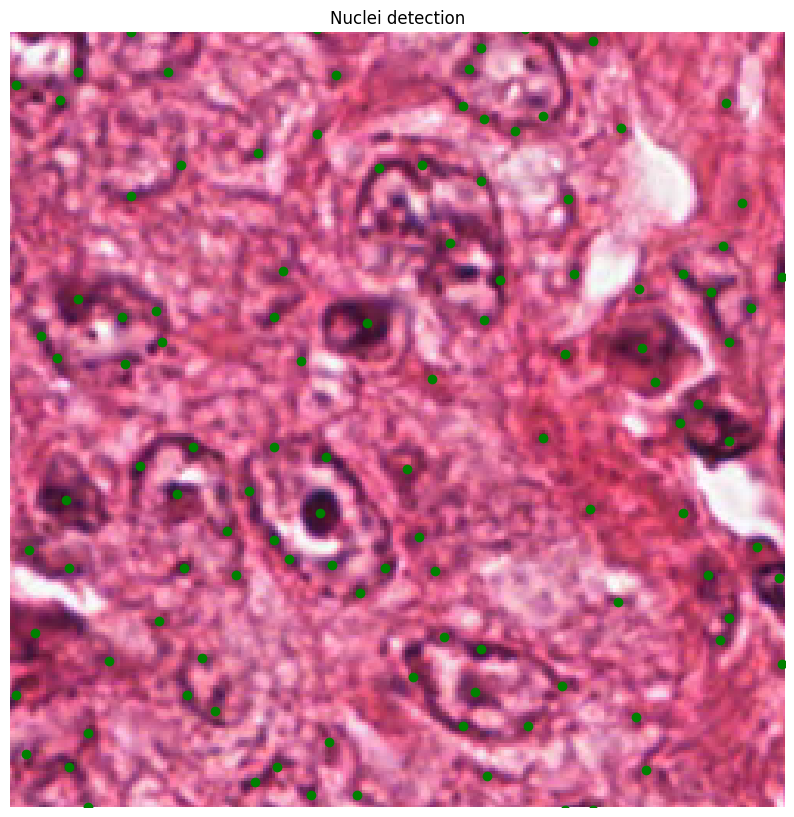

In [6]:

## -- Your code here -- ##
from skimage.color import rgb2hsv
from skimage.feature import blob_log

# We get the Value Channel from HSV Color space
im_hsv = rgb2hsv(im)
channel_V = im_hsv[:, :, 2] 

# Invert (we search for dark nuclei)
channel_V_inv = 1.0 - channel_V

blobs = blob_log(channel_V_inv, min_sigma=4, max_sigma=10, num_sigma=4, threshold=0.1)

print(f"{len(blobs)} nuclei detected")

plt.figure(figsize=(10,20))
plt.imshow(im)

plt.plot(blobs[:,1], blobs[:,0], 'go', alpha=1)
plt.xlim([750,1000])
plt.ylim([1000,1250])

plt.title("Nuclei detection")
plt.axis("off")
plt.show()


## Descriptors

The goal of *descriptors* is to represent the region surrounding the point of interest in a way that allow our algorithm to best perform its task. For instance, the BRIEF descriptor will compare pairs of pixels in the given neighbourhood and create a binary descriptor representing the result of all these comparison. This kind of descriptor will tend to create a unique signature in a grayscale image, and is very useful for applications such as matching for stereo-vision or for video tracking.

Other types of descriptors can be based on the texture (for instance with local Fourier transforms) or on local histograms.

* Using the points detected before, **extract neighbourhood patches** and **compute the concatenated color histogram** as a descriptor (meaning a 256+256+256 = size 768 vector, with the first 256 values corresponding to the R histogram, etc...).
* Use the [KMeans](http://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html) class from `scikit-learn` to cluster the points of interest depending on their descriptor. Can you identify clusters representing the type of tissue of the cell?

Size of descriptor matrix: (6951, 768)


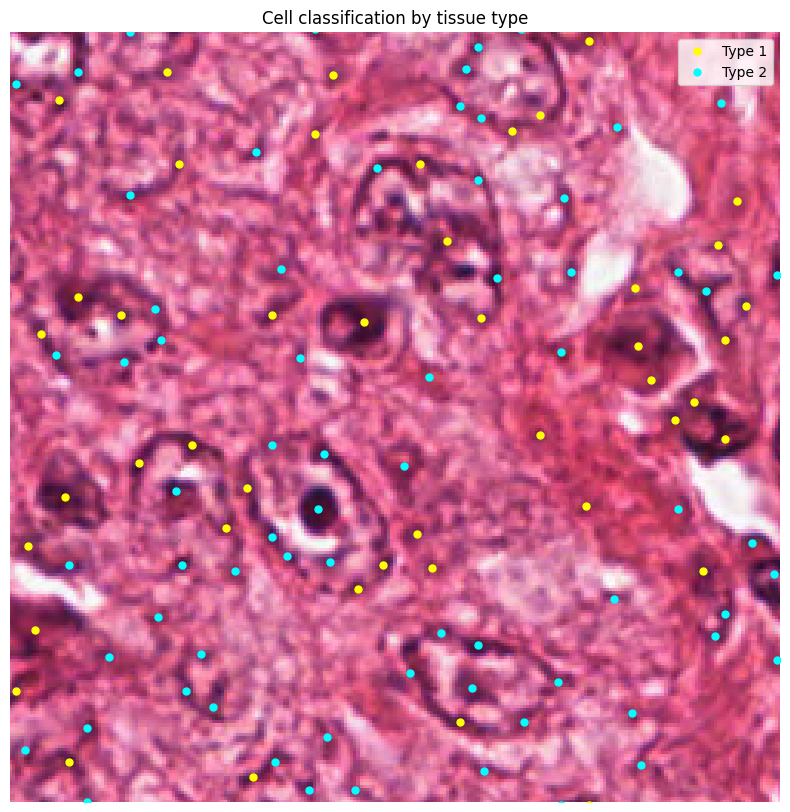

In [ ]:
from sklearn.cluster import KMeans

def compute_histogram(patch):
    rgb_histogram = np.zeros((768,))
    
    ## DONE : compute histogram ##

    # convert to 'int' to make sure we can go beyond 255
    r = patch[:, :, 0].flatten().astype(int)
    g = patch[:, :, 1].flatten().astype(int)
    b = patch[:, :, 2].flatten().astype(int)
    for i in range(len(r)):
        # RED (0 to 255)
        rgb_histogram[r[i]] += 1

        #GREEN (256 to 511)
        rgb_histogram[g[i] + 256] += 1

        #BLUE (512 to 767)
        rgb_histogram[b[i] + (2*256)] += 1

        # Normalization
        rgb_histogram = rgb_histogram / np.sum(rgb_histogram)

    return rgb_histogram

def extract_descriptors(im, coords, neighbourhood_size=15):
    ## TODO : extract neighbourhood patch for each point coordinate, 
    ## compute histogram and compile everything in a "descriptor matrix"
    descriptors = []

    half = neighbourhood_size // 2

    for coord in coords:
        y, x = int(coord[0]), int(coord[1])

        # Make sure we don't go out the image
        y_min = max(0, y - half)
        y_max = min(im.shape[0], y + half + 1)
        x_min = max(0, x - half)
        x_max = min(im.shape[1], x + half + 1)

        # Cut a small square in the image
        patch = im[y_min:y_max, x_min:x_max]

        # Compute histogram
        desc = compute_histogram(patch)
        descriptors.append(desc)


    return np.array(descriptors)

## -- Your code here -- ##
from sklearn.cluster import KMeans

# EXTRACT DESCRIPTORS
descriptors = extract_descriptors(im, blobs, neighbourhood_size=15)
print(f"Size of descriptor matrix: {descriptors.shape}")

# ------------------------------------------- KMEANS CLUSTERING
n_clusters = 2

kmeans = KMeans(n_clusters=n_clusters, random_state=42)

# Give a label to each cell (0 or 1)
labels = kmeans.fit_predict(descriptors)

# Display results
plt.figure(figsize=(10,10))
plt.imshow(im)

# 1 color per label
colors = ['yellow', 'cyan']

for i in range(n_clusters):
    # Keep blobs from cluster 'i' only
    cluster_points = blobs[labels == i]

    plt.plot(cluster_points[:, 1], cluster_points[:, 0], 'o', color=colors[i], markersize=5, label=f"Type {i+1}")

plt.title(f"Cell classification by tissue type")
plt.xlim([750,1000])
plt.ylim([1000,1250])
plt.legend()
plt.axis("off")
plt.show()



* Apply the same point detection and descriptors on the `mitosis2.bmp` image, and use the already trained KMeans to predict the clusters of the points in the new image.

6868 nuclei detected
Size of descriptor matrix: (6868, 768)


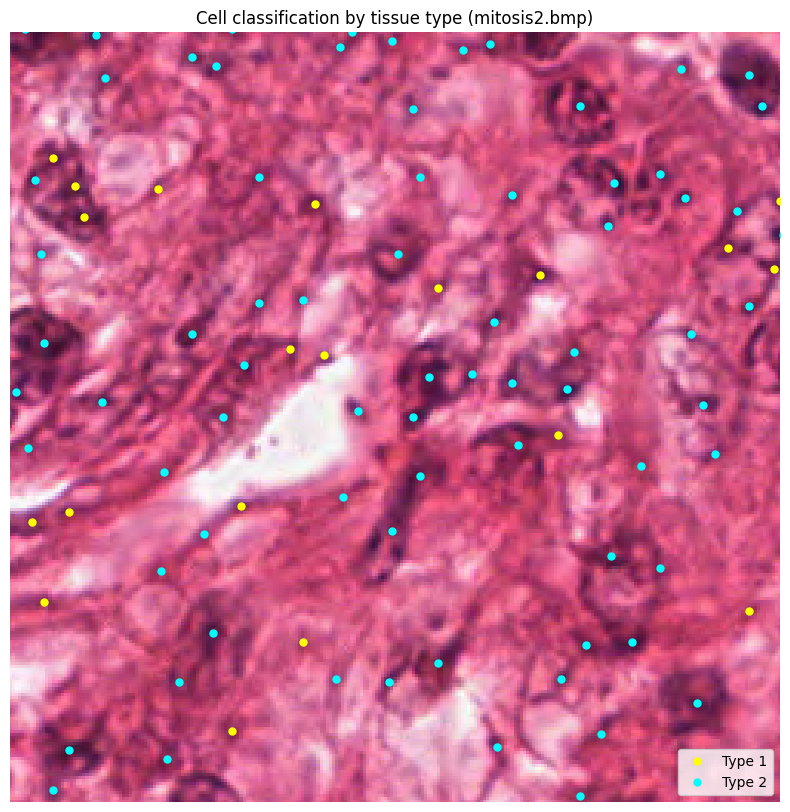

In [ ]:

## -- Your code here -- ##
im2 = imread('mitosis2.bmp')

# ------------------------------------------- POINT DETECTION
# We get the Value Channel from HSV Color space
im2_hsv = rgb2hsv(im2)
channel_V2 = im2_hsv[:, :, 2] 

# Invert (we search for dark nuclei)
channel_V_inv2 = 1.0 - channel_V2

blobs2 = blob_log(channel_V_inv2, min_sigma=4, max_sigma=10, num_sigma=4, threshold=0.1)

print(f"{len(blobs2)} nuclei detected")

descriptors2 = extract_descriptors(im2, blobs2, neighbourhood_size=15)
print(f"Size of descriptor matrix: {descriptors2.shape}")

# Give a label to each cell (0 or 1) (use already trained Kmeans to predict clusters)
labels2 = kmeans.predict(descriptors2)

# Display results
plt.figure(figsize=(10,10))
plt.imshow(im2)

for i in range(n_clusters):
    # Keep blobs from cluster 'i' only
    cluster_points = blobs2[labels2 == i]

    plt.plot(cluster_points[:, 1], cluster_points[:, 0], 'o', color=colors[i], markersize=5, label=f"Type {i+1}")

plt.title(f"Cell classification by tissue type (mitosis2.bmp)")
plt.xlim([750,1000])
plt.ylim([1000,1250])
plt.legend()
plt.axis("off")
plt.show()

